In [136]:
!pip install torchmetrics

In [137]:
# Import all relevant dependencies
import torch
from torch import nn, cuda, optim

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import v2

# Matplotlib and numpy for visualization
import matplotlib.pyplot as plt
import numpy as np

# Check versions
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.9.0+cu128
torchvision version: 0.24.0+cu128


In [138]:
# First, set up the appropriate transform
my_transform = v2.Compose([
  # Resize the image to a reasonably large size
  v2.Resize(size=(256, 256)),
  # distort the colors occassionally to improve model's image recognition
  v2.RandomPhotometricDistort(p=0.4),
  # Convert to grayscale to deal with less color channels
  v2.Grayscale(),
  # Flip image horizontally every now and then to make model more resilient to distortion
  v2.RandomHorizontalFlip(p=0.55),
  # Equivalent to v2.ToTensor(), which is now deprecated
  v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32, scale=True)
  ])
])

# Set up training data
train_data = datasets.MNIST(
  root="data", # Where the data will be downloaded in the home directory
  train=True,
  download=True,
  transform=my_transform,
  target_transform=None
)
test_data = datasets.MNIST(
  root="data",
  train=False,
  download=True,
  transform=my_transform,
  target_transform=None
)

my_transform, train_data, test_data

(Compose(
       Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomPhotometricDistort(brightness=(0.875, 1.125), contrast=(0.5, 1.5), hue=(-0.05, 0.05), saturation=(0.5, 1.5), p=0.4)
       Grayscale(num_output_channels=1)
       RandomHorizontalFlip(p=0.55)
       Compose(
         ToImage()
         ToDtype(scale=True)
   )
 ),
 Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: Compose(
                  Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomPhotometricDistort(brightness=(0.875, 1.125), contrast=(0.5, 1.5), hue=(-0.05, 0.05), saturation=(0.5, 1.5), p=0.4)
                  Grayscale(num_output_channels=1)
                  RandomHorizontalFlip(p=0.55)
                  Compose(
                    ToImage()
                    ToDtype(scale=True)
              )
            ),
 Dataset MNIST
     Nu

In [139]:
# Check out an example of the data
image, label = train_data[0]
image, label

(Image([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], ),
 5)

In [140]:
# Check out the shape of the image
image.shape

torch.Size([1, 256, 256])

In [141]:
# Gather number of samples
len(train_data), len(test_data)

(60000, 10000)

In [142]:
# Gather class names...
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

Image shape: torch.Size([1, 256, 256])


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

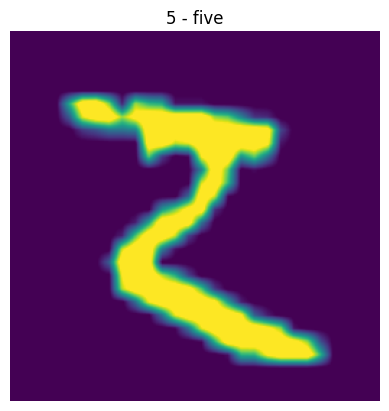

In [143]:
# Visualize our data
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(class_names[label])
plt.axis(False)

Text(0.5, 1.0, '5 - five')

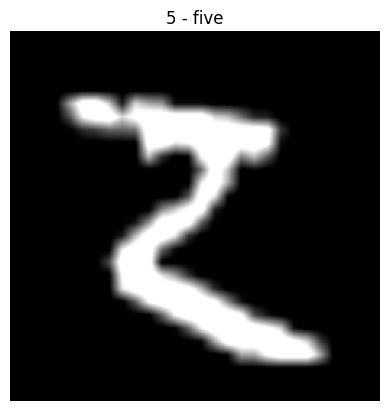

In [144]:
# Show the same image in grayscale
plt.imshow(image.squeeze(), cmap="gray")
plt.axis(False)
plt.title(class_names[label])

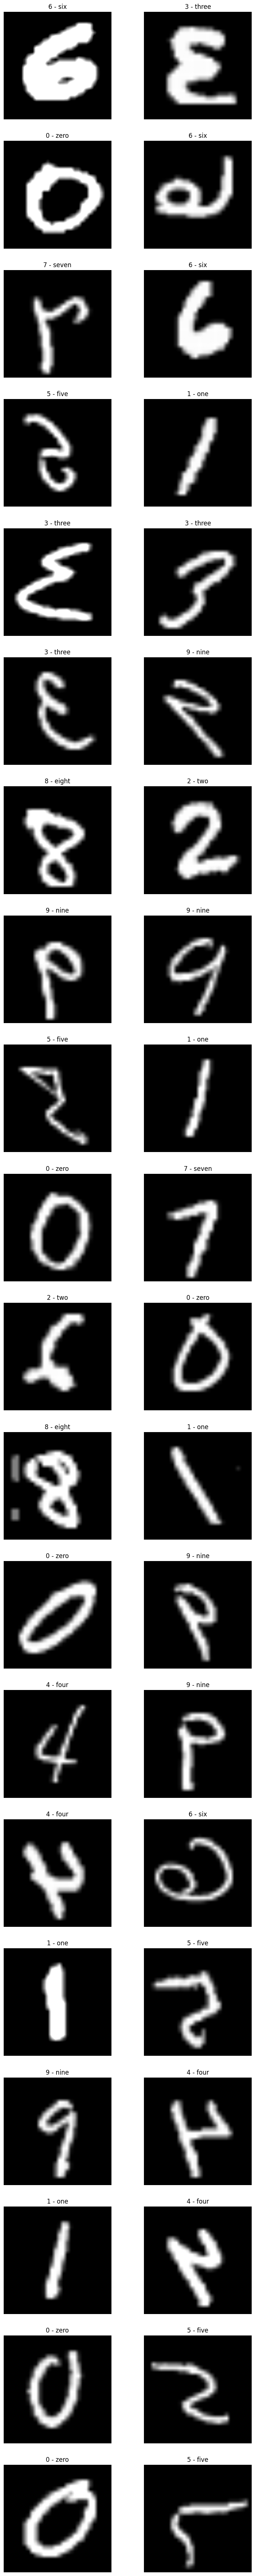

In [145]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 90))
rows, cols = 20, 2
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx] # type: ignore
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

In [146]:
# Create DataLoaders for our training and testing sets...
from torch.utils.data import DataLoader

# Chosen batch size to be a power of 2 for good practices
BATCH_SIZE = 64

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(
  dataset=train_data,
  batch_size=BATCH_SIZE,
  num_workers=16,
  shuffle=True
)
test_dataloader = DataLoader(
  dataset=test_data,
  batch_size=BATCH_SIZE,
  num_workers=8,
  shuffle=False
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d8d3c30a1e0>, <torch.utils.data.dataloader.DataLoader object at 0x7d8a49becaa0>)
Length of train dataloader: 938 batches of 64
Length of test dataloader: 157 batches of 64


In [147]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([64, 1, 256, 256]), torch.Size([64]))

Image size: torch.Size([1, 256, 256])
Label: 3, label size: torch.Size([])


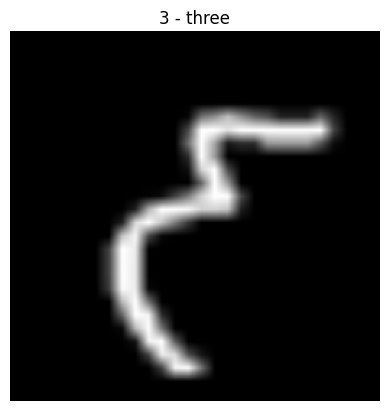

In [148]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off")
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

In [149]:
# set device
D = torch.device("cuda:0") if cuda.is_available() else torch.device("cpu")

In [150]:
# Create a Convolutional Neural Network
class TinyVGGImageNetModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
    )
    self.conv_block_2 = nn.Sequential(
      nn.Dropout(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=1)
    )
    self.classifier = nn.Sequential(
      nn.Flatten(),
      # TODO: Edit in_features later to remove tensor mismatch errors.
      nn.Linear(in_features=390150, out_features=output_shape)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.classifier(self.conv_block_2((self.conv_block_1(x))))


# Test model
torch.manual_seed(42)
model = TinyVGGImageNetModel(input_shape=1,
    hidden_units=6,
    output_shape=len(class_names)).to(D)
model

TinyVGGImageNetModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=390150, out_features=10, bias=True)
  )
)

In [151]:
# Loss function, optimizer, and scheduler
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9995)
loss_fn, optimizer, scheduler

(CrossEntropyLoss(),
 Adam (
 Parameter Group 0
     amsgrad: False
     betas: (0.9, 0.999)
     capturable: False
     decoupled_weight_decay: False
     differentiable: False
     eps: 1e-08
     foreach: None
     fused: None
     initial_lr: 0.001
     lr: 0.001
     maximize: False
     weight_decay: 0
 ),
 <torch.optim.lr_scheduler.ExponentialLR at 0x7d8a49a623f0>)

In [152]:
# Write the functions for my metrics...
# Because such functions for >2 classes are already written, torchmetrics
# is used to acquire them
from torchmetrics.classification import (MulticlassAccuracy, MulticlassPrecision,
                                          MulticlassRecall, MulticlassF1Score)

def calc_accuracy(y_preds: torch.Tensor, y: torch.Tensor) -> float:
  mca = MulticlassAccuracy(num_classes=len(class_names)).to(D)
  return mca(y_preds, y)

def calc_precision(y_preds: torch.Tensor, y: torch.Tensor) -> float:
  mcp = MulticlassPrecision(num_classes=len(class_names)).to(D)
  return mcp(y_preds, y)

def calc_recall(y_preds: torch.Tensor, y: torch.Tensor) -> float:
  mcr = MulticlassRecall(num_classes=len(class_names)).to(D)
  return mcr(y_preds, y)

def calc_f1(y_preds: torch.Tensor, y: torch.Tensor) -> float:
  mcf = MulticlassF1Score(num_classes=len(class_names)).to(D)
  return mcf(y_preds, y)

def calc_metrics(y_preds: torch.Tensor, y: torch.Tensor) -> tuple[float, float, float, float]:
  return (calc_accuracy(y_preds, y), calc_precision(y_preds, y),
          calc_recall(y_preds, y), calc_f1(y_preds, y))

In [153]:
# Writing function for training steps
def train_step(model: nn.Module, dataloader: DataLoader,
               loss_fn: nn.Module, optimizer: optim.Optimizer, scheduler: optim.lr_scheduler.ExponentialLR,
               metrics_fn = calc_metrics, device = D) -> tuple[list[float], list[float], list[float], list[float], list[float]]:
  # Declare metrics and lists to store them
  train_loss, train_acc, train_precision, train_recall, train_f1 = 0.0, 0.0, 0.0, 0.0, 0.0
  current_train_acc, current_train_precision, current_train_recall, current_train_f1 = 0.0, 0.0, 0.0, 0.0
  model.to(device)
  losses, accs, precisions, recalls, f1s = [], [], [], [], []
  # Set model to training mode before iterating
  model.train()
  for batch, (X, y) in enumerate(dataloader):
      # Send all the data to the appropriate device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_preds = model(X)

      # 2. Calculate the Loss (and other metrics)
      loss = loss_fn(y_preds, y)
      (current_train_acc, current_train_precision,
      current_train_recall, current_train_f1) = metrics_fn(y_preds, y)
      train_loss += loss.item()
      train_acc += current_train_acc
      train_precision += current_train_precision
      train_recall += current_train_recall
      train_f1 += current_train_f1

      # 3. Optimizer zero grad...
      optimizer.zero_grad()

      # 4. Backward
      loss.backward()

      # 5. Optimizer step...
      optimizer.step()

  # Update optimizer through scheduler
  scheduler.step()

  # Calculate loss and accuracy per epoch and print out what's happening
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  train_precision /= len(dataloader)
  train_recall /= len(dataloader)
  train_f1 /= len(dataloader)

  # Store everything for displaying on plots later
  losses.append(train_loss)
  accs.append(train_acc)
  precisions.append(train_precision)
  recalls.append(train_recall)
  f1s.append(train_f1)

  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f} | Train precision: {train_precision:.2f} | Train recall: {train_recall:.2f} | Train f1: {train_f1:.2f}")
  return losses, accs, precisions, recalls, f1s


In [154]:
# Writing evaluation function for valEidation step
def test_step(model: nn.Module, dataloader: DataLoader,
              loss_fn: nn.Module, optimizer: optim.Optimizer,
              metrics_fn = calc_metrics, device = D) -> tuple[float, float, float, float, float]:
  # Store metrics
  loss, acc, precision, recall, f1 = 0.0, 0.0, 0.0, 0.0, 0.0
  cum_acc, cum_precision, cum_recall, cum_f1 = 0.0, 0.0, 0.0, 0.0
  # Fist, set model to eval mode
  model.eval()
  with torch.inference_mode():
    for X, y in dataloader:
      # Send data to the target device
      X, y = X.to(device), y.to(device)
      y_preds = model(X)
      # Update metrics
      loss += loss_fn(y_preds, y).item()
      cum_acc, cum_precision, cum_recall, cum_f1 = metrics_fn(y_preds, y)
      acc += cum_acc
      precision += cum_precision
      recall += cum_recall
      f1 += cum_f1
    # Scale loss other metrics
    loss /= len(dataloader)
    acc /= len(dataloader)
    precision /= len(dataloader)
    recall /= len(dataloader)
    f1 /= len(dataloader)
    print(f"\nTest loss: {loss:.2f} | Test accuracy: {acc:.2f} | Test precision: {precision:.2f} | Test recall: {recall:.2f} | Test F1: {f1:.2f}")
    return loss, acc, precision, recall, f1

In [155]:
!pip install tqdm

In [156]:

from tqdm import tqdm
losses, accs, precisions, recalls, f1s = [], [], [], [], []
epochss = []
test_losses, test_accs, test_precisions, test_recalls, test_f1s = [], [], [], [], []
epochs = 30
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    epochss.append(epoch)
    loss, acc, precision, recall, f1 = train_step(model=model, dataloader=train_dataloader,
               loss_fn=loss_fn, optimizer=optimizer, scheduler=scheduler)
    losses.append(loss)
    accs.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(recall)
    test_loss, test_acc, test_precision, test_recall, test_f1 = test_step(model=model,
                                                                          dataloader=test_dataloader,
                                                                          loss_fn=loss_fn,
                                                                          optimizer=optimizer)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    test_precisions.append(test_precision)
    test_recalls.append(test_recall)
    test_f1s.append(test_f1)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.64561 | Train accuracy: 0.80 | Train precision: 0.80 | Train recall: 0.80 | Train f1: 0.78


  3%|▎         | 1/30 [00:20<09:47, 20.26s/it]


Test loss: 0.85 | Test accuracy: 0.69 | Test precision: 0.74 | Test recall: 0.69 | Test F1: 0.66
Epoch: 1
---------
Train loss: 0.47538 | Train accuracy: 0.85 | Train precision: 0.85 | Train recall: 0.85 | Train f1: 0.83


  7%|▋         | 2/30 [00:40<09:26, 20.23s/it]

...


Test loss: 0.48 | Test accuracy: 0.88 | Test precision: 0.89 | Test recall: 0.88 | Test F1: 0.88
Epoch: 28
---------
Train loss: 0.07539 | Train accuracy: 0.97 | Train precision: 0.97 | Train recall: 0.97 | Train f1: 0.97


 97%|█████████▋| 29/30 [09:55<00:20, 20.51s/it]


Test loss: 0.51 | Test accuracy: 0.88 | Test precision: 0.89 | Test recall: 0.88 | Test F1: 0.88
Epoch: 29
---------
Train loss: 0.07195 | Train accuracy: 0.97 | Train precision: 0.97 | Train recall: 0.97 | Train f1: 0.97


100%|██████████| 30/30 [10:15<00:00, 20.53s/it]


Test loss: 0.54 | Test accuracy: 0.87 | Test precision: 0.88 | Test recall: 0.87 | Test F1: 0.87


In [157]:
# Write a function for plotting metrics using matplotlib
import matplotlib.pyplot as plt
def plot_metric(metric_name: str, train_metric: list, test_metric: list, epochs: int):
  # Convert tensors to CPU and then to float for plotting
  # train_metric (e.g., accs) is a list of lists containing a single tensor
  if(metric_name != "Loss"):
    train_metric_cpu = [item[0].cpu().item() for item in train_metric]
    # test_metric (e.g., test_accs) is a list of single tensors
    test_metric_cpu = [item.cpu().item() for item in test_metric]
  else:
    train_metric_cpu = [item[0] for item in train_metric] # Extract the float from the inner list
    test_metric_cpu = test_metric # This is already a list of floats

  plt.figure(figsize=(10, 6))
  plt.axis((0, epochs, 0, (max(max(test_metric_cpu), max(train_metric_cpu))) * 1.1)) # Add some buffer to max for better visualization
  plt.plot(epochss, train_metric_cpu, label=f"Training {metric_name}")
  plt.plot(epochss, test_metric_cpu, label=f"Testing {metric_name}")
  plt.xlabel("Epochs")
  plt.ylabel(metric_name)
  plt.legend()
  plt.title(f"Model's {metric_name} over Time")
  plt.grid(True)
  plt.show()

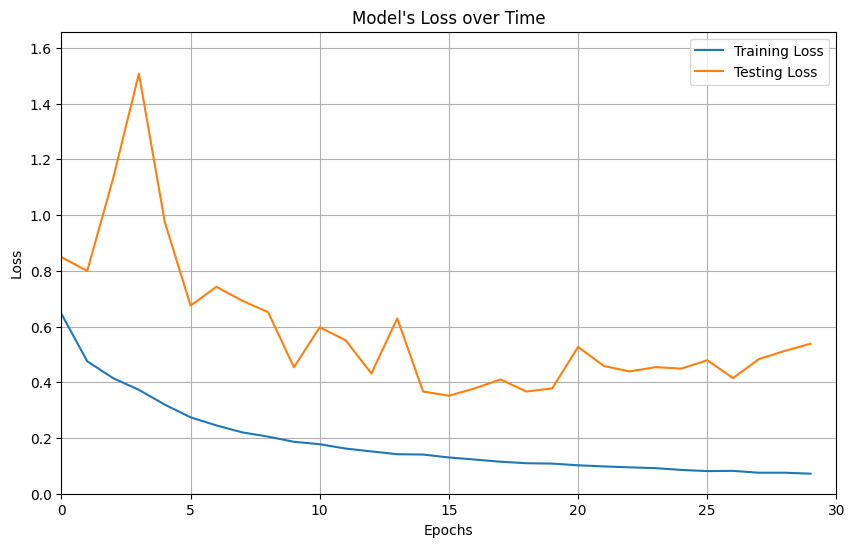

In [158]:
# Display Loss over time
plot_metric("Loss", losses, test_losses, epochs)

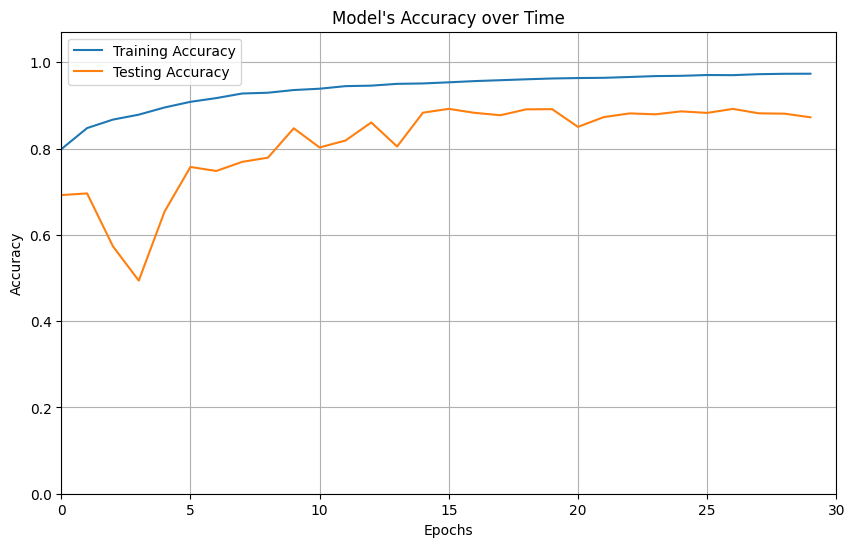

In [159]:
# Display accuracy over time
plot_metric("Accuracy", accs, test_accs, epochs)

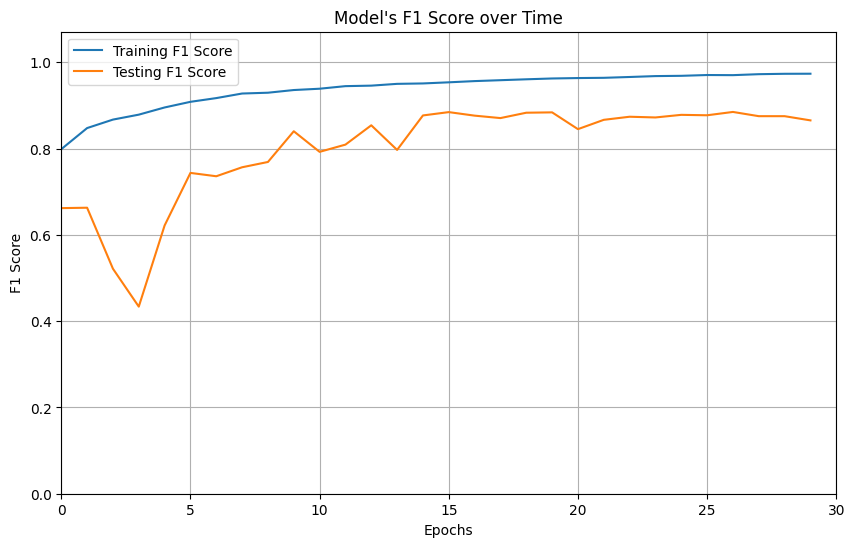

In [161]:
# Display f1 score over time
plot_metric("F1 Score", f1s, test_f1s, epochs)